In [39]:
import pandas as pd
import re
import string
import nltk
from nltk.corpus import stopwords

df = pd.read_csv('../data/tweets_labeled.csv')

df = df.dropna(subset=['tweet'])

nltk.download('stopwords')
stop_words = set(stopwords.words('turkish'))
extra_stopwords = {'bir', 'mi', 'mu', 'mı', 'mu', 'tweet', 'twitter'}
stop_words.update(extra_stopwords)


def full_clean(text):
    if not isinstance(text, str):
        return ""
    
    text = text.replace('İ', 'i').replace('I', 'ı').lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)
    
   
    words = text.split()
    words = [w for w in words if w not in stop_words]
    
    return " ".join(words).strip()


df['clean_text'] = df['tweet'].apply(full_clean)


print("İlk aşama başarıyla tamamlandı!")
print("Sütunlar:", df.columns)
df[['tweet', 'clean_text']].head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\miray\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


İlk aşama başarıyla tamamlandı!
Sütunlar: Index(['tweet_id', 'tweet', 'date', 'label', 'clean_text'], dtype='object')


,tweet,clean_text
0,Berk Ali (kedim) seni çok özledim. Ölmek için ...,berk ali kedim seni özledim ölmek küçücüktün s...
1,"Yani, öylesine ciddiye alacaksın ki yaşamayı, ...",öylesine ciddiye alacaksın yaşamayı yetmişinde...
2,saçlarının gölgesinde\nölmek ne güzeldi,saçlarının gölgesinde ölmek güzeldi
3,"Öyle güzel baktın ki, gözlerime\nsevmek değil ...",öyle güzel baktın gözlerime sevmek değil ölmek...
4,sevmek biri için ölmek değil her şeye rağmen y...,sevmek ölmek değil şeye rağmen yaşayabilmek miş


In [40]:
import re
import string

def clean_turkish_text(text):
    
    if not isinstance(text, str):
        return ""

    text = text.replace('İ', 'i').replace('I', 'ı').lower()
    
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    text = re.sub(r'@\w+|#\w+', '', text)

    text = text.translate(str.maketrans('', '', string.punctuation))
 
    text = re.sub(r'\d+', '', text)

    text = text.strip()
    return text

In [41]:

df = df.dropna(subset=['tweet'])

# hücreler arası kopukluk olmaması için yeniden tanımlama 
def full_clean(text):
    if not isinstance(text, str):
        return ""
   
    text = text.replace('İ', 'i').replace('I', 'ı').lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)
    
   
    words = text.split()
    words = [w for w in words if w not in stop_words]
    
    return " ".join(words).strip()


# .apply() sonucunu yeni bir sütun olarak atıyoruz
df['clean_text'] = df['tweet'].apply(full_clean)


print("Sütunlar:", df.columns)
df[['tweet', 'clean_text']].head()

Sütunlar: Index(['tweet_id', 'tweet', 'date', 'label', 'clean_text'], dtype='object')


,tweet,clean_text
0,Berk Ali (kedim) seni çok özledim. Ölmek için ...,berk ali kedim seni özledim ölmek küçücüktün s...
1,"Yani, öylesine ciddiye alacaksın ki yaşamayı, ...",öylesine ciddiye alacaksın yaşamayı yetmişinde...
2,saçlarının gölgesinde\nölmek ne güzeldi,saçlarının gölgesinde ölmek güzeldi
3,"Öyle güzel baktın ki, gözlerime\nsevmek değil ...",öyle güzel baktın gözlerime sevmek değil ölmek...
4,sevmek biri için ölmek değil her şeye rağmen y...,sevmek ölmek değil şeye rağmen yaşayabilmek miş


In [42]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# (Sütun adlarının 'clean_text' ve 'label' olduğunu varsayıyoruz)
X = df['clean_text']
y = df['label']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

vectorizer = TfidfVectorizer(max_features=5000) 
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Veri hazırlığı tamamlandı!")
print(f"Eğitim seti boyutu: {X_train_tfidf.shape}")

Veri hazırlığı tamamlandı!
Eğitim seti boyutu: (10367, 5000)


In [43]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

# Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
nb_preds = nb_model.predict(X_test_tfidf)

# SVM
svm_model = SVC(kernel='linear')
svm_model.fit(X_train_tfidf, y_train)
svm_preds = svm_model.predict(X_test_tfidf)


print("--- Naive Bayes Sonuçları ---")
print(classification_report(y_test, nb_preds))

print("\n--- SVM Sonuçları ---")
print(classification_report(y_test, svm_preds))

--- Naive Bayes Sonuçları ---
              precision    recall  f1-score   support

          -1       0.74      0.13      0.22       567
           0       0.68      0.98      0.80      1695
           1       0.84      0.13      0.22       330

    accuracy                           0.69      2592
   macro avg       0.75      0.41      0.41      2592
weighted avg       0.71      0.69      0.60      2592


--- SVM Sonuçları ---
              precision    recall  f1-score   support

          -1       0.67      0.29      0.41       567
           0       0.72      0.94      0.81      1695
           1       0.74      0.30      0.43       330

    accuracy                           0.71      2592
   macro avg       0.71      0.51      0.55      2592
weighted avg       0.71      0.71      0.67      2592



In [44]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

#  Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)
lr_preds = lr_model.predict(X_test_tfidf)

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100)
rf_model.fit(X_train_tfidf, y_train)
rf_preds = rf_model.predict(X_test_tfidf)

#  K-Nearest Neighbors (K-NN)
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_tfidf, y_train)
knn_preds = knn_model.predict(X_test_tfidf)

print("Tüm modeller eğitildi!")

Tüm modeller eğitildi!


In [45]:
results = {
    'Model': ['Naive Bayes', 'SVM', 'Logistic Regression', 'Random Forest', 'K-NN'],
    'Accuracy': [
        accuracy_score(y_test, nb_preds),
        accuracy_score(y_test, svm_preds),
        accuracy_score(y_test, lr_preds),
        accuracy_score(y_test, rf_preds),
        accuracy_score(y_test, knn_preds)
    ]
}

df_results = pd.DataFrame(results)
print(df_results.sort_values(by='Accuracy', ascending=False))

                 Model  Accuracy
1                  SVM  0.714120
2  Logistic Regression  0.706404
3        Random Forest  0.695602
0          Naive Bayes  0.685571
4                 K-NN  0.652778


In [46]:
from sklearn.ensemble import VotingClassifier

# En iyi performans gösteren ilk 3 model


voting_model = VotingClassifier(
    estimators=[
        ('svm', SVC(kernel='linear')), 
        ('lr', LogisticRegression(max_iter=1000)), 
        ('rf', RandomForestClassifier(n_estimators=100))
    ],
    voting='hard' # Çoğunluk oyu
)

# Melez model
voting_model.fit(X_train_tfidf, y_train)


voting_preds = voting_model.predict(X_test_tfidf)

print("--- Ensemble (Voting) Sonuçları ---")
print(classification_report(y_test, voting_preds))
print("Ensemble Accuracy:", accuracy_score(y_test, voting_preds))

--- Ensemble (Voting) Sonuçları ---
              precision    recall  f1-score   support

          -1       0.67      0.28      0.40       567
           0       0.72      0.94      0.81      1695
           1       0.77      0.29      0.42       330

    accuracy                           0.71      2592
   macro avg       0.72      0.50      0.54      2592
weighted avg       0.71      0.71      0.67      2592

Ensemble Accuracy: 0.7133487654320988


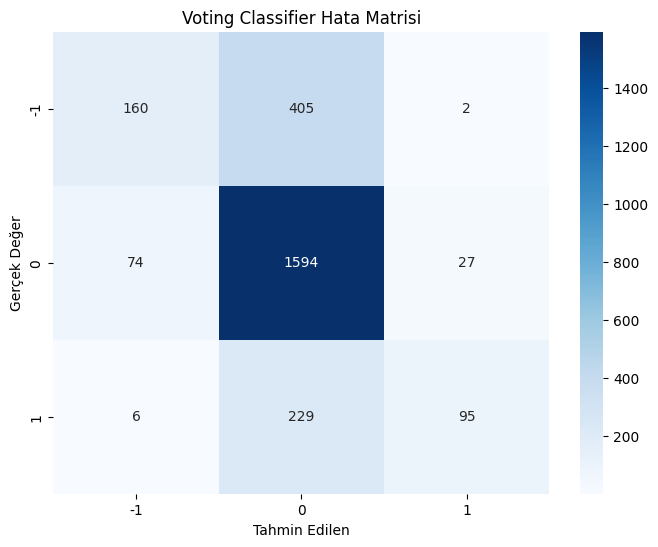

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, voting_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[-1, 0, 1], yticklabels=[-1, 0, 1])
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')
plt.title('Voting Classifier Hata Matrisi')
plt.show()

In [48]:
import pandas as pd


df_turkish = pd.read_csv('../data/TurkishTweets.csv')
try:
    df_tweetset = pd.read_csv('../data/tweetset.csv', encoding='utf-16')
except UnicodeDecodeError:
    try:
        # utf-16 işe yaramazsa standart Windows Türkçe kodlamasını dene
        df_tweetset = pd.read_csv('../data/tweetset.csv', encoding='cp1254') 
    except UnicodeDecodeError:
        df_tweetset = pd.read_csv('../data/tweetset.csv', encoding='latin1')

print("Dosyalar başarıyla okundu!\n")


print("--- TurkishTweets.csv İncelemesi ---")
print("Sütunlar:", df_turkish.columns.tolist())
print("Boyut:", df_turkish.shape)
print("\nİlk 3 Satır:")
print(df_turkish.head(3))

print("\n" + "="*50 + "\n")

print("--- tweetset.csv İncelemesi ---")
print("Sütunlar:", df_tweetset.columns.tolist())
print("Boyut:", df_tweetset.shape)
print("\nİlk 3 Satır:")
print(df_tweetset.head(3))

Dosyalar başarıyla okundu!

--- TurkishTweets.csv İncelemesi ---
Sütunlar: ['Tweet', 'Etiket']
Boyut: (4000, 2)

İlk 3 Satır:
                                               Tweet  Etiket
0  Allah'ım çıldıracağım. Yemin ederim çıldıracağ...  kızgın
1  site ne zaman çalıştıda ürün stokları bitti di...  kızgın
2    Sebebi neydi ki diye bağıracağım şimdi az kaldı  kızgın


--- tweetset.csv İncelemesi ---
Sütunlar: ['Tip', 'Paylaşım', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5']
Boyut: (11111, 6)

İlk 3 Satır:
       Tip                                           Paylaşım Unnamed: 2  \
0  Negatif                      Doğa ağzımıza sıçsa hakkı var        NaN   
1  Pozitif  Anne bir sanatçıdır, en güzel eseri de yavrusu...        NaN   
2  Negatif   ibrahimin oğlunu koruyan Tanrı’ya da ben sokayım        NaN   

   Unnamed: 3 Unnamed: 4 Unnamed: 5  
0         NaN        NaN        NaN  
1         NaN        NaN        NaN  
2         NaN        NaN        NaN  


In [49]:

df_ek = df_tweetset[['Paylaşım', 'Tip']].copy()

df_ek = df_ek.rename(columns={'Paylaşım': 'tweet', 'Tip': 'label'})

# 'Pozitif' ve 'Negatif' kelimelerini  1 ve -1'e çevirdk
duygu_sozlugu = {
    'Pozitif': 1, 'pozitif': 1, 
    'Negatif': -1, 'negatif': -1, 
    'Nötr': 0, 'nötr': 0
}
df_ek['label'] = df_ek['label'].map(duygu_sozlugu)
df_ek = df_ek.dropna(subset=['label'])


# iki veri setini birleştirdik
df_birlestirilmis = pd.concat([df[['tweet', 'label']], df_ek], ignore_index=True)


print("Yeni Veri Seti Boyutu:", df_birlestirilmis.shape)
print("\nYeni Duygu Dağılımı:")
print(df_birlestirilmis['label'].value_counts())

Yeni Veri Seti Boyutu: (24069, 2)

Yeni Duygu Dağılımı:
label
 0.0    8448
-1.0    7903
 1.0    7718
Name: count, dtype: int64


In [50]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score



df_birlestirilmis['clean_text'] = df_birlestirilmis['tweet'].apply(full_clean)

X_yeni = df_birlestirilmis['clean_text']
y_yeni = df_birlestirilmis['label']


X_train_yeni, X_test_yeni, y_train_yeni, y_test_yeni = train_test_split(X_yeni, y_yeni, test_size=0.2, random_state=42)

#özellik sayısını arttır
vectorizer_yeni = TfidfVectorizer(max_features=10000)
X_train_tfidf_yeni = vectorizer_yeni.fit_transform(X_train_yeni)
X_test_tfidf_yeni = vectorizer_yeni.transform(X_test_yeni)


#svm
svm_yeni = SVC(kernel='linear')
svm_yeni.fit(X_train_tfidf_yeni, y_train_yeni)
svm_yeni_preds = svm_yeni.predict(X_test_tfidf_yeni)

# Majority Voting (Melez Model)
voting_yeni = VotingClassifier(
    estimators=[
        ('svm', SVC(kernel='linear')), 
        ('lr', LogisticRegression(max_iter=1000)), 
        ('rf', RandomForestClassifier(n_estimators=100))
    ],
    voting='hard'
)
voting_yeni.fit(X_train_tfidf_yeni, y_train_yeni)
voting_yeni_preds = voting_yeni.predict(X_test_tfidf_yeni)

print("\n" + "="*40)
print("yeni sonuçlar")
print("="*40)

print("SVM Sonuçları")
print(classification_report(y_test_yeni, svm_yeni_preds))
print("SVM Accuracy:", accuracy_score(y_test_yeni, svm_yeni_preds))

print(" Ensemble (Voting) Sonuçları")
print(classification_report(y_test_yeni, voting_yeni_preds))
print("Voting Accuracy:", accuracy_score(y_test_yeni, voting_yeni_preds))

1. Metinler temizleniyor (Bu işlem biraz sürebilir)...
2. Veriler ayrılıyor ve sayısallaştırılıyor...
3. Modeller eğitiliyor (SVM ve Voting Classifier)...

yeni sonuçlar
SVM Sonuçları
              precision    recall  f1-score   support

        -1.0       0.71      0.67      0.69      1514
         0.0       0.68      0.73      0.70      1732
         1.0       0.68      0.66      0.67      1568

    accuracy                           0.69      4814
   macro avg       0.69      0.69      0.69      4814
weighted avg       0.69      0.69      0.69      4814

SVM Accuracy: 0.6884088076443706
 Ensemble (Voting) Sonuçları
              precision    recall  f1-score   support

        -1.0       0.73      0.67      0.70      1514
         0.0       0.68      0.73      0.70      1732
         1.0       0.69      0.68      0.68      1568

    accuracy                           0.70      4814
   macro avg       0.70      0.69      0.70      4814
weighted avg       0.70      0.70      0.70    

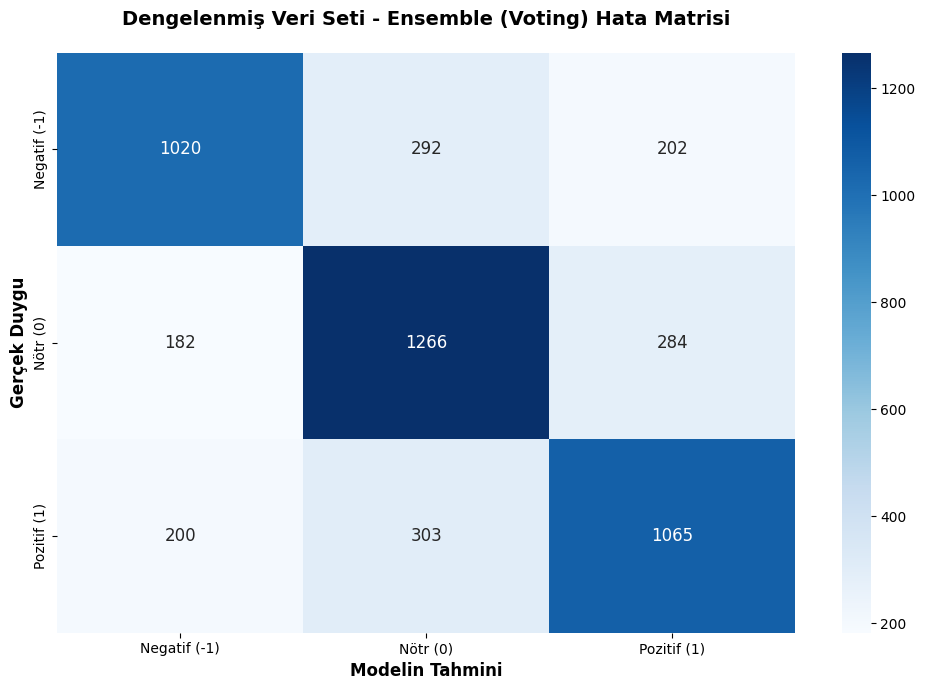

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

#votinge göre
cm_yeni = confusion_matrix(y_test_yeni, voting_yeni_preds)
plt.figure(figsize=(10, 7))

sns.heatmap(cm_yeni, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negatif (-1)', 'Nötr (0)', 'Pozitif (1)'], 
            yticklabels=['Negatif (-1)', 'Nötr (0)', 'Pozitif (1)'],
            annot_kws={"size": 12})

plt.xlabel('Modelin Tahmini', fontsize=12, fontweight='bold')
plt.ylabel('Gerçek Duygu', fontsize=12, fontweight='bold')
plt.title('Dengelenmiş Veri Seti - Ensemble (Voting) Hata Matrisi', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

In [52]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

#ngram_range=(1, 2) ekledik hem tek hem çift okusun diye
vectorizer_ngram = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))

X_train_tfidf_ngram = vectorizer_ngram.fit_transform(X_train_yeni)
X_test_tfidf_ngram = vectorizer_ngram.transform(X_test_yeni)



# SVM
svm_ngram = SVC(kernel='linear')
svm_ngram.fit(X_train_tfidf_ngram, y_train_yeni)
svm_ngram_preds = svm_ngram.predict(X_test_tfidf_ngram)

# Voting Classifier
voting_ngram = VotingClassifier(
    estimators=[
        ('svm', SVC(kernel='linear')), 
        ('lr', LogisticRegression(max_iter=1000)), 
        ('rf', RandomForestClassifier(n_estimators=100))
    ],
    voting='hard'
)
voting_ngram.fit(X_train_tfidf_ngram, y_train_yeni)
voting_ngram_preds = voting_ngram.predict(X_test_tfidf_ngram)

print("\n" + "="*40)
print(" N-GRAM (1, 2) SONUÇLARI ")
print("="*40)

print("\nYeni SVM Sonuçlar")
print("SVM Accuracy:", accuracy_score(y_test_yeni, svm_ngram_preds))
print(classification_report(y_test_yeni, svm_ngram_preds))

print("\n Yeni Ensemble (Voting) Sonuçları ")
print("Voting Accuracy:", accuracy_score(y_test_yeni, voting_ngram_preds))
print(classification_report(y_test_yeni, voting_ngram_preds))



 N-GRAM (1, 2) SONUÇLARI 

Yeni SVM Sonuçlar
SVM Accuracy: 0.6852928957208143
              precision    recall  f1-score   support

        -1.0       0.71      0.66      0.68      1514
         0.0       0.68      0.73      0.70      1732
         1.0       0.67      0.66      0.67      1568

    accuracy                           0.69      4814
   macro avg       0.69      0.68      0.68      4814
weighted avg       0.69      0.69      0.68      4814


 Yeni Ensemble (Voting) Sonuçları 
Voting Accuracy: 0.6963024511840465
              precision    recall  f1-score   support

        -1.0       0.73      0.67      0.70      1514
         0.0       0.68      0.73      0.71      1732
         1.0       0.68      0.68      0.68      1568

    accuracy                           0.70      4814
   macro avg       0.70      0.69      0.70      4814
weighted avg       0.70      0.70      0.70      4814



In [53]:
from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.1, 1, 10, 100], 'kernel': ['linear', 'rbf']}
grid_search = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train_tfidf_ngram, y_train_yeni)

print("En iyi parametreler:", grid_search.best_params_)
print("En iyi CV skoru:", grid_search.best_score_)

best_svm = grid_search.best_estimator_
best_preds = best_svm.predict(X_test_tfidf_ngram)
print("Test Accuracy:", accuracy_score(y_test_yeni, best_preds))

Fitting 5 folds for each of 8 candidates, totalling 40 fits
En iyi parametreler: {'C': 1, 'kernel': 'rbf'}
En iyi CV skoru: 0.6886522981043884
Test Accuracy: 0.6919401744910677


In [54]:
from sklearn.model_selection import cross_val_score
import time

modeller = {
    'Naive Bayes': nb_model,
    'SVM': svm_model,
    'Logistic Regression': lr_model,
    'Random Forest': rf_model,
    'K-NN': knn_model,
    'Voting Classifier': voting_model
}

sonuclar = []
for isim, model in modeller.items():
    baslangic = time.time()
    cv_skorlar = cross_val_score(model, X_train_tfidf_ngram, y_train_yeni, cv=5, scoring='f1_macro')
    sure = time.time() - baslangic
    sonuclar.append({
        'Model': isim,
        'CV F1 Ortalama': cv_skorlar.mean().round(4),
        'CV F1 Std': cv_skorlar.std().round(4),
        'Süre (sn)': round(sure, 2)
    })

df_sonuc = pd.DataFrame(sonuclar).sort_values('CV F1 Ortalama', ascending=False)
print(df_sonuc)

                 Model  CV F1 Ortalama  CV F1 Std  Süre (sn)
5    Voting Classifier          0.6865     0.0067     299.70
2  Logistic Regression          0.6835     0.0067       3.25
1                  SVM          0.6764     0.0062     107.94
3        Random Forest          0.6724     0.0063     150.81
0          Naive Bayes          0.6660     0.0093       0.12
4                 K-NN          0.4016     0.0115       5.75


In [55]:
from scipy.stats import wilcoxon

# En iyi iki modeli karşılaştır
svm_skorlar = cross_val_score(svm_model, X_train_tfidf_ngram, y_train_yeni, cv=5)
voting_skorlar = cross_val_score(voting_model, X_train_tfidf_ngram, y_train_yeni, cv=5)

stat, p_value = wilcoxon(svm_skorlar, voting_skorlar)
print(f"p-value: {p_value}")
if p_value < 0.05:
    print("Fark istatistiksel olarak anlamlı")
else:
    print("Fark istatistiksel olarak anlamlı değil")

p-value: 0.0625
Fark istatistiksel olarak anlamlı değil


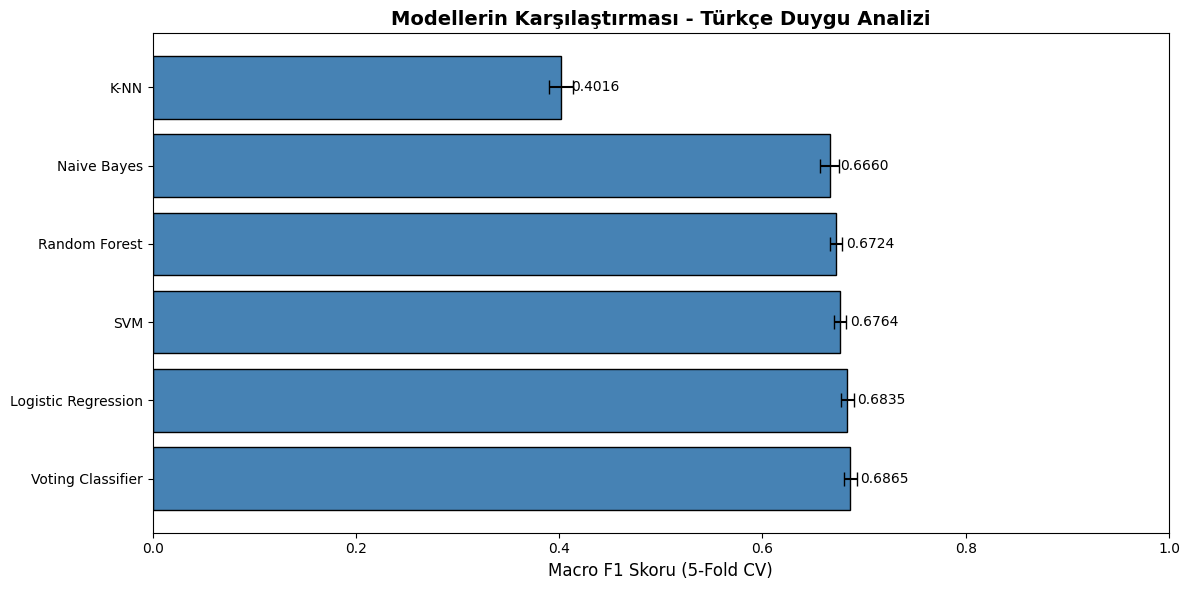

In [56]:
import matplotlib.pyplot as plt
import numpy as np

model_isimleri = df_sonuc['Model']
f1_ortalama = df_sonuc['CV F1 Ortalama']
f1_std = df_sonuc['CV F1 Std']

plt.figure(figsize=(12, 6))
bars = plt.barh(model_isimleri, f1_ortalama, xerr=f1_std, 
                color='steelblue', edgecolor='black', capsize=5)
plt.xlabel('Macro F1 Skoru (5-Fold CV)', fontsize=12)
plt.title('Modellerin Karşılaştırması - Türkçe Duygu Analizi', fontsize=14, fontweight='bold')
plt.xlim(0, 1)
for bar, val in zip(bars, f1_ortalama):
    plt.text(val + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{val:.4f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()